<a href="https://colab.research.google.com/github/bsc1990/Cases-FIAP/blob/main/case_vinhos_fiap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## | Importação, Tratamento e Validação da Base


In [2]:
import pandas as pd

# Carregar datasets
base_vinho = pd.read_csv ('/content/base_WineQT.csv')

In [3]:
base_vinho.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
## Dimensão da base
print(base_vinho.shape)

(1143, 13)


In [5]:
# Criar uma cópia da base original
base_vinho_tratada = base_vinho.copy()

# Padronizar os nomes das colunas
base_vinho_tratada.columns = (
    base_vinho_tratada.columns
    .str.strip()                         # Remove espaços no início e no final
    .str.lower()                         # Converte para letras minúsculas
    .str.replace(r'\s+', '_', regex=True) # Substitui espaços por "_"
)

# Conferir os novos nomes
print(base_vinho_tratada.columns.tolist())

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality', 'id']


In [6]:
## Tratamento da Base

display(
    base_vinho_tratada.head(10).style.hide(axis="index")
)

fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,0
7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5,1
7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5,2
11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6,3
7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,4
7.400000,0.660000,0.000000,1.800000,0.075000,13.000000,40.000000,0.997800,3.510000,0.560000,9.400000,5,5
7.900000,0.600000,0.060000,1.600000,0.069000,15.000000,59.000000,0.996400,3.300000,0.460000,9.400000,5,6
7.300000,0.650000,0.000000,1.200000,0.065000,15.000000,21.000000,0.994600,3.390000,0.470000,10.000000,7,7
7.800000,0.580000,0.020000,2.000000,0.073000,9.000000,18.000000,0.996800,3.360000,0.570000,9.500000,7,8
6.700000,0.580000,0.080000,1.800000,0.097000,15.000000,65.000000,0.995900,3.280000,0.540000,9.200000,5,10


In [7]:
## Remover coluna ID
base_vinho_tratada = base_vinho_tratada.drop(columns=['id'])

# Contar duplicidades
quantidade_duplicados = base_vinho_tratada.duplicated().sum()

print("Duplicidades:", quantidade_duplicados)

Duplicidades: 125


In [8]:
# Remover duplicidades
base_vinho_tratada = (
    base_vinho_tratada
    .drop_duplicates()
    .reset_index(drop=True)
)
print("Duplicidades:", quantidade_duplicados)
print("Base tratada:", base_vinho_tratada.shape)

Duplicidades: 125
Base tratada: (1018, 12)


In [9]:
# Verificar dados ausentes
print("Valores ausentes por coluna:")
print( base_vinho_tratada.isnull().sum())

# Verificar os tipos das colunas
print("\nTipos das colunas:")
print( base_vinho_tratada.dtypes)

# Verificar os valores da variável quality
print("\nValores encontrados em quality:")
print( base_vinho_tratada['quality'].value_counts().sort_index())

# Verificar valores negativos nas colunas numéricas
colunas_numericas = base_vinho_tratada.select_dtypes(include='number').columns
print("\nValores negativos por coluna:")
print( (base_vinho_tratada[colunas_numericas] < 0).sum())

Valores ausentes por coluna:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Tipos das colunas:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores encontrados em quality:
quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

Valores negativos por coluna:
fixed_acidity           0
volatile_acidity        0
citric_acid             

In [10]:
display(
    base_vinho_tratada.head(10))

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
5,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
6,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
7,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
8,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5
9,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,5


## | Criação e Validação de Variável Binária

In [11]:
# Criar a variável-alvo binária
base_vinho_tratada['alta_qualidade'] = (
    base_vinho_tratada['quality'] >= 7
).astype(int)

# Conferir a distribuição
print(base_vinho_tratada['alta_qualidade'].value_counts())

print("\nDistribuição percentual:")
print(
    base_vinho_tratada['alta_qualidade']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
display(
    base_vinho_tratada.head(10))

alta_qualidade
0    881
1    137
Name: count, dtype: int64

Distribuição percentual:
alta_qualidade
0    86.54
1    13.46
Name: proportion, dtype: float64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,alta_qualidade
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
5,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
6,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,1
7,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,1
8,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0
9,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,5,0


## || MODELO 1 - REGRESSÃO LOGÍSTICA
# | Separação de Variáveis

In [12]:
from sklearn.model_selection import train_test_split

# Variáveis utilizadas para fazer a previsão
X = base_vinho_tratada.drop(
    columns=['quality', 'alta_qualidade']
)

# Variável que queremos prever
y = base_vinho_tratada['alta_qualidade']

# Separação entre treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensão do conjunto de treino:", X_treino.shape)
print("Dimensão do conjunto de teste:", X_teste.shape)

print("\nDistribuição da variável-alvo no treino:")
print(y_treino.value_counts())

print("\nDistribuição da variável-alvo no teste:")
print(y_teste.value_counts())

Dimensão do conjunto de treino: (814, 11)
Dimensão do conjunto de teste: (204, 11)

Distribuição da variável-alvo no treino:
alta_qualidade
0    704
1    110
Name: count, dtype: int64

Distribuição da variável-alvo no teste:
alta_qualidade
0    177
1     27
Name: count, dtype: int64


## | Pipeline da Regressão Logística

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_regressao_logistica = Pipeline([

    # Padronizar as escalas das variáveis
    ('padronizacao', StandardScaler()),

    # Criar o modelo
    ('modelo', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Treinar o modelo
pipeline_regressao_logistica.fit(
    X_treino,
    y_treino
)

print("Regressão Logística OK!")

Regressão Logística OK!


## | Previsões e Calculo de Métricas

In [14]:
# Previsão da classificação
y_pred_regressao = pipeline_regressao_logistica.predict(X_teste)

# Probabilidade de o vinho ser de alta qualidade
y_prob_regressao = pipeline_regressao_logistica.predict_proba(
    X_teste
)[:, 1]


# Cálculo de Métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
resultado_regressao_logistica = pd.DataFrame({
    'modelo': ['Regressão Logística'],
    'acuracia': [
        accuracy_score(y_teste, y_pred_regressao)
        ],

    'precisao': [
                  precision_score(
                  y_teste,
                  y_pred_regressao,
                  zero_division=0
                  )
                ],

    'recall': [
                recall_score(y_teste, y_pred_regressao)
              ],

    'f1_score': [
                f1_score(y_teste, y_pred_regressao)
                ],

    'roc_auc': [
                roc_auc_score(y_teste, y_prob_regressao)
                ]
})

print ('Métricas')
display(
    resultado_regressao_logistica.style.format({
                                                'acuracia': '{:.2%}',
                                                'precisao': '{:.2%}',
                                                'recall': '{:.2%}',
                                                'f1_score': '{:.2%}',
                                                'roc_auc': '{:.2%}'
                                            })
)

Métricas


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%


## | Classificação

In [15]:
from sklearn.metrics import classification_report

print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_regressao,
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.79      0.86       177
       Alta Qualidade       0.36      0.78      0.49        27

             accuracy                           0.78       204
            macro avg       0.66      0.78      0.68       204
         weighted avg       0.88      0.78      0.81       204



## | Matriz de Confusão

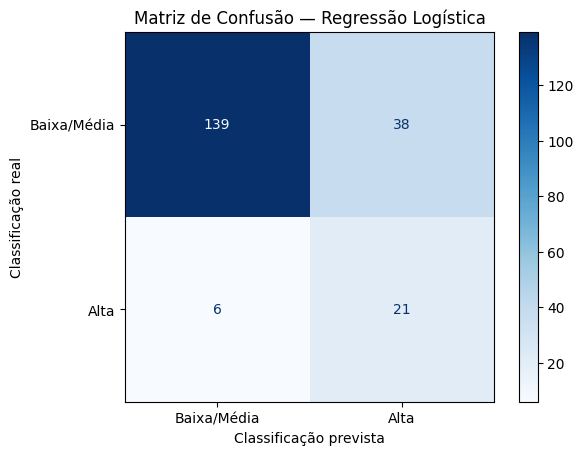

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_regressao,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Blues',
    values_format='d'
)

plt.title('Matriz de Confusão — Regressão Logística')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

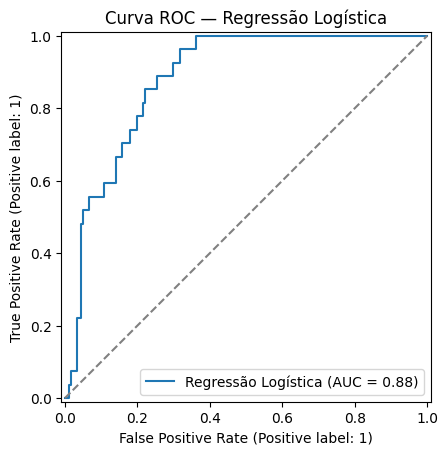

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_regressao,
    name='Regressão Logística'
)

plt.title('Curva ROC — Regressão Logística')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)
plt.show()

Nota:

A Regressão Logística identificou 77,78% dos vinhos de alta qualidade e apresentou um ROC-AUC de 88,18%, mostrando boa capacidade de diferenciar os dois grupos. Porém, a precisão ficou em 35,59%, o que mostra que vários vinhos foram classificados como alta qualidade sem de fato pertencerem a essa categoria. Portanto, neste primeiro momento, o modelo parece funcionar melhor como apoio em uma triagem inicial do que para definir sozinho a qualidade final do vinho.

## || MODELO 2 - KNN

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## | Pipeline de KNN

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_knn = Pipeline([

  # Padronizar as variáveis
  ('padronizacao', StandardScaler()),

  # Criar o modelo KNN
  ('modelo', KNeighborsClassifier(
      n_neighbors=5,
      weights='distance'
  ))
])

# Treinar o modelo
pipeline_knn.fit(
    X_treino,
    y_treino
)

print("KNN OK!")


KNN OK!


## | Previsão e Cálculo de Métricas de KNN

In [20]:

# Previsão da classificação
y_pred_knn = pipeline_knn.predict(X_teste)

# Probabilidade de alta qualidade
y_prob_knn = pipeline_knn.predict_proba(
    X_teste
)[:, 1]

print("Previsões de KNN OK!")



# Cálculo de Métricas
resultado_knn = pd.DataFrame({
    'modelo': ['KNN'],

    'acuracia': [
        accuracy_score(y_teste, y_pred_knn)
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_knn,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_knn
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_knn
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_knn
        )
    ]
})

display(
    resultado_knn.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)


Previsões de KNN OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,KNN,88.24%,57.14%,44.44%,50.00%,86.47%


# | Classificação


In [21]:
print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_knn,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.92      0.95      0.93       177
       Alta Qualidade       0.57      0.44      0.50        27

             accuracy                           0.88       204
            macro avg       0.74      0.70      0.72       204
         weighted avg       0.87      0.88      0.88       204



# | Matriz de Confusão

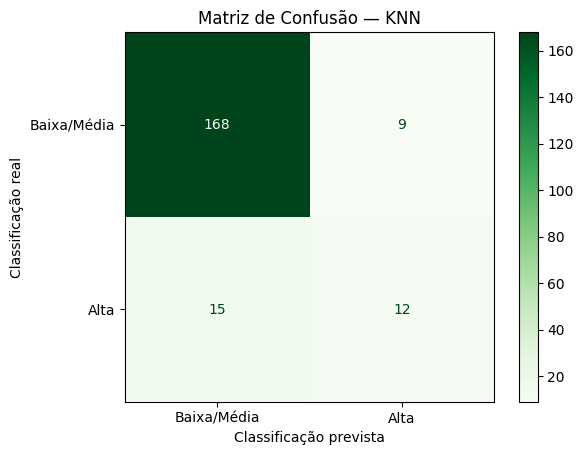

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_knn,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Greens',
    values_format='d'
)

plt.title('Matriz de Confusão — KNN')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

# | Curva ROC

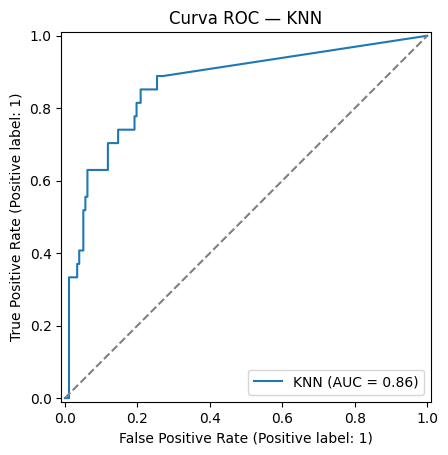

In [23]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_knn,
    name='KNN'
)

plt.title('Curva ROC — KNN')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

# | Comparação com Regressão Logística

In [24]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn
], ignore_index=True)

print ('Comparação entre KNN e Regressão Logística')
display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Comparação entre KNN e Regressão Logística


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%


Nota:

O KNN teve acurácia de 88,24% e precisão de 57,14%, resultados superiores aos da Regressão Logística. Porém o modelo identificou apenas 44,44% dos vinhos de alta qualidade, deixando de encontrar 15 dos 27 vinhos superiores presentes na base de teste. Dessa forma, o KNN mostrou ser mais preciso quando classifica um vinho como alta qualidade, mas apresentou uma capacidade menor de identificar todos os vinhos que pertencem a essa categoria.


## || MODELO 3 - SVN

## | Pipeline de SVN

In [25]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_svm = Pipeline([

    # Padronizar as variáveis
    ('padronizacao', StandardScaler()),

    # Criar o modelo SVM
    ('modelo', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

# Treinar o modelo
pipeline_svm.fit(
    X_treino,
    y_treino
)

print("SVM OK!")

SVM OK!


## | Previsão e Cálculo de Métricas

In [26]:
# Previsão da classificação
y_pred_svm = pipeline_svm.predict(X_teste)

# Probabilidade de alta qualidade
y_prob_svm = pipeline_svm.predict_proba(
    X_teste
)[:, 1]

print("Previsões do SVM OK!")



#Cálculo de Métricas
resultado_svm = pd.DataFrame({
    'modelo': ['SVM'],

    'acuracia': [
        accuracy_score(y_teste, y_pred_svm)
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_svm,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_svm
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_svm
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_svm
        )
    ]
})

display(
    resultado_svm.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)



Previsões do SVM OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,SVM,82.84%,41.67%,74.07%,53.33%,90.19%


## | Classificação

In [31]:

print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_svm,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.84      0.89       177
       Alta Qualidade       0.42      0.74      0.53        27

             accuracy                           0.83       204
            macro avg       0.69      0.79      0.71       204
         weighted avg       0.88      0.83      0.85       204



## | Matriz de Confusão

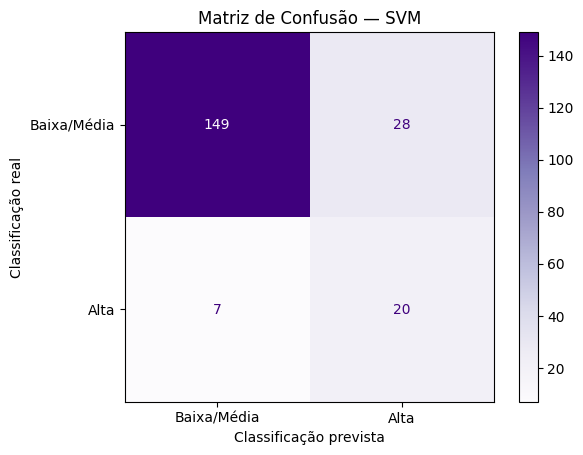

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_svm,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Purples',
    values_format='d'
)

plt.title('Matriz de Confusão — SVM')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

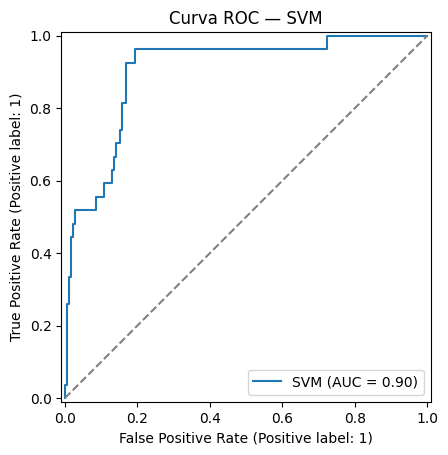

In [29]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_svm,
    name='SVM'
)

plt.title('Curva ROC — SVM')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

## | Comparação

In [30]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn,
    resultado_svm
], ignore_index=True)

display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%
2,SVM,82.84%,41.67%,74.07%,53.33%,90.19%


Nota:

O SVM teve acurácia de 82,84% e identificou 74,07% dos vinhos de alta qualidade. Apesar de o recall ter ficado um pouco abaixo do resultado da Regressão Logística, o modelo reduziu a quantidade de falsos positivos e aumentou a precisão para 41,67%. Além disso, apresentou os melhores resultados de F1-score e ROC-AUC entre os três modelos testados até o momento. Com isso, o SVM se mostrou o modelo mais equilibrado nesta primeira comparação.


## || MODELO 4 - Random Forest

## | Pipeline de Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline_random_forest = Pipeline([

    ('modelo', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Treinar o modelo
pipeline_random_forest.fit(
    X_treino,
    y_treino
)

print("Random Forest OK!")

Random Forest OK!


## | Previsão e Cálculo de Métricas

In [33]:
# Previsão da classificação
y_pred_random_forest = pipeline_random_forest.predict(
    X_teste
)

# Probabilidade de alta qualidade
y_prob_random_forest = pipeline_random_forest.predict_proba(
    X_teste
)[:, 1]

print("Previsões do Random Forest OK!")



#Cálculo de Métricas
resultado_random_forest = pd.DataFrame({
    'modelo': ['Random Forest'],

    'acuracia': [
        accuracy_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_random_forest,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_random_forest
        )
    ]
})

display(
    resultado_random_forest.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Previsões do Random Forest OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Random Forest,90.69%,75.00%,44.44%,55.81%,92.43%


## | Classificação

In [34]:
print('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_random_forest,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.92      0.98      0.95       177
       Alta Qualidade       0.75      0.44      0.56        27

             accuracy                           0.91       204
            macro avg       0.84      0.71      0.75       204
         weighted avg       0.90      0.91      0.90       204



## | Matriz de Confusão

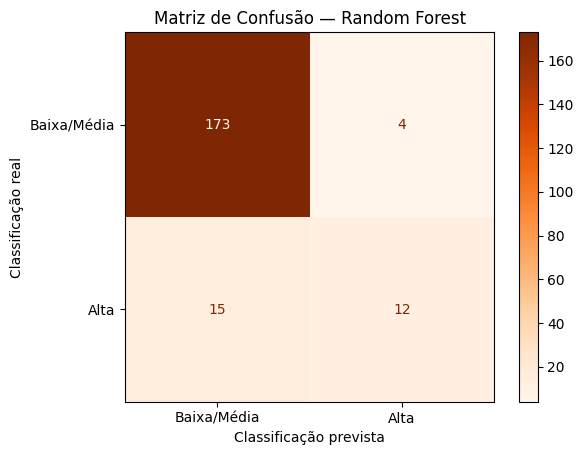

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_random_forest,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Oranges',
    values_format='d'
)

plt.title('Matriz de Confusão — Random Forest')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

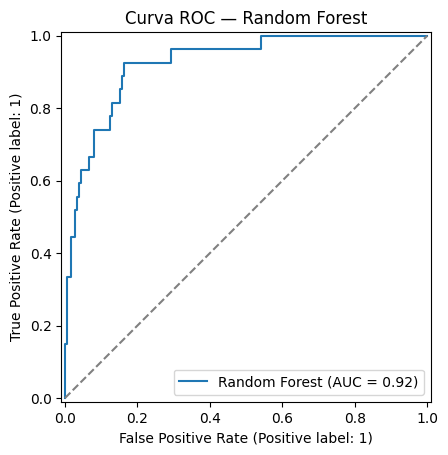

In [36]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_random_forest,
    name='Random Forest'
)

plt.title('Curva ROC — Random Forest')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

## | Variáveis

,variavel,importancia
10,alcohol,21.94%
1,volatile_acidity,13.24%
9,sulphates,13.06%
2,citric_acid,10.30%
7,density,8.49%
4,chlorides,7.61%
6,total_sulfur_dioxide,6.51%
0,fixed_acidity,5.47%
3,residual_sugar,4.78%
8,ph,4.52%


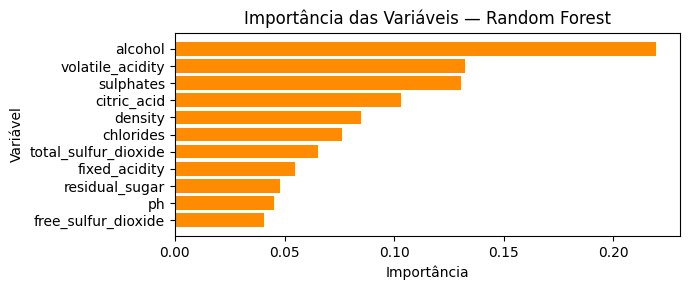

In [40]:
# Acessar o modelo dentro do pipeline
modelo_random_forest = (
    pipeline_random_forest.named_steps['modelo']
)

# Criar tabela com a importância das variáveis
importancia_variaveis = pd.DataFrame({
    'variavel': X_treino.columns,
    'importancia': modelo_random_forest.feature_importances_
}).sort_values(
    by='importancia',
    ascending=False
)

display(
    importancia_variaveis.style.format({
        'importancia': '{:.2%}'
    })
)



#Gráfico
importancia_grafico = importancia_variaveis.sort_values(
    by='importancia',
    ascending=True
)

plt.figure(figsize=(7, 3))

plt.barh(
    importancia_grafico['variavel'],
    importancia_grafico['importancia'],
    color='darkorange'
)

plt.title('Importância das Variáveis — Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

## | Comparação

In [41]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn,
    resultado_svm,
    resultado_random_forest
], ignore_index=True)

display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%
2,SVM,82.84%,41.67%,74.07%,53.33%,90.19%
3,Random Forest,90.69%,75.00%,44.44%,55.81%,92.43%


Nota:

O Random Forest apresentou os melhores resultados de acurácia, precisão, F1-score e ROC-AUC se comparado com os três outros modelos testados. O modelo teve uma precisão de 75%, o que mostra uma boa taxa de acerto entre os vinhos classificados como alta qualidade. Porém, conseguiu identificar apenas 44,44% dos vinhos que realmente pertenciam a essa categoria. Dessa forma, o Random Forest se mostrou mais confiável quando aponta um vinho como alta qualidade, mas ainda deixa passar uma quantidade relevante de vinhos superiores.

## || Testes e Validações

## | Validação Cruzada

In [44]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import make_scorer
from sklearn.dummy import DummyClassifier

# Criar as métricas de avaliação
metricas_cv = {
    'acuracia': 'accuracy',

    'precisao': make_scorer(
        precision_score,
        zero_division=0
    ),

    'recall': make_scorer(
        recall_score,
        zero_division=0
    ),

    'f1_score': make_scorer(
        f1_score,
        zero_division=0
    ),

    'roc_auc': 'roc_auc'
}

# Criar cinco divisões estratificadas
validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelos que serão avaliados
modelos_cv = {
    'Dummy — Referência': DummyClassifier(
        strategy='most_frequent'
    ),

    'Regressão Logística': pipeline_regressao_logistica,

    'KNN': pipeline_knn,

    'SVM': pipeline_svm,

    'Random Forest': pipeline_random_forest
}


#Executar Validação Cruzada

resultados_cv = []

for nome_modelo, modelo in modelos_cv.items():

    scores = cross_validate(
        estimator=modelo,
        X=X,
        y=y,
        cv=validacao_cruzada,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_cv.append({
        'modelo': nome_modelo,

        'acuracia_media':
            scores['test_acuracia'].mean(),

        'precisao_media':
            scores['test_precisao'].mean(),

        'recall_medio':
            scores['test_recall'].mean(),

        'f1_medio':
            scores['test_f1_score'].mean(),

        'roc_auc_medio':
            scores['test_roc_auc'].mean(),

        'f1_desvio':
            scores['test_f1_score'].std(),

        'roc_auc_desvio':
            scores['test_roc_auc'].std()
    })

resultados_validacao_cruzada = pd.DataFrame(
    resultados_cv
)

# Visualizar Resultados
resultados_validacao_cruzada = (
    resultados_validacao_cruzada
    .sort_values(
        by='f1_medio',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultados_validacao_cruzada.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}',
        'roc_auc_desvio': '{:.2%}'
    })
)

,modelo,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio,roc_auc_desvio
0,Regressão Logística,79.77%,38.58%,81.08%,52.11%,87.80%,3.66%,2.25%
1,SVM,81.14%,39.76%,75.90%,52.05%,87.87%,4.76%,2.23%
2,Random Forest,88.71%,60.93%,42.46%,49.42%,88.40%,9.62%,3.18%
3,KNN,87.23%,52.94%,42.43%,46.64%,82.87%,9.89%,5.15%
4,Dummy — Referência,86.54%,0.00%,0.00%,0.00%,50.00%,0.00%,0.00%


Nota:

Após a validação cruzada, a Regressão Logística retornou o maior recall médio e o melhor F1-score, além de demonstrar maior estabilidade entre as diferentes divisões da base. O SVM teve um resultado muito próximo e também se mostrou uma boa alternativa. Já o Random Forest apresentou a maior precisão e o melhor ROC-AUC, mas encontrou uma parcela menor dos vinhos de alta qualidade e teve variação maior entre os testes.

Obs.: Esses resultados mostram a importância de não escolher o modelo com base em uma única divisão dos dados.

## || Teste de Features

In [45]:
# Criar uma cópia das variáveis originais
X_features_derivadas = X.copy()

# Relação entre dióxido de enxofre livre e total
X_features_derivadas['free_total_so2_ratio'] = (
    X_features_derivadas['free_sulfur_dioxide']
    / (
        X_features_derivadas['total_sulfur_dioxide']
        + 0.000001
    )
)

# Quantidade estimada de dióxido de enxofre combinado
X_features_derivadas['bound_sulfur_dioxide'] = (
    X_features_derivadas['total_sulfur_dioxide']
    - X_features_derivadas['free_sulfur_dioxide']
)

# Relação entre acidez volátil e acidez fixa
X_features_derivadas['volatile_fixed_acidity_ratio'] = (
    X_features_derivadas['volatile_acidity']
    / (
        X_features_derivadas['fixed_acidity']
        + 0.000001
    )
)

print("Quantidade de features originais:", X.shape[1])
print(
    "Quantidade após a criação das features:",
    X_features_derivadas.shape[1]
)

display(X_features_derivadas.head())

Quantidade de features originais: 11
Quantidade após a criação das features: 14


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,free_total_so2_ratio,bound_sulfur_dioxide,volatile_fixed_acidity_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.323529,23.0,0.094595
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0.373134,42.0,0.112820
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0.277778,39.0,0.097436
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0.283333,43.0,0.025000
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0.325000,27.0,0.089189


## | Validação dos Modelos com as Features e Comparação com as Features Originais

In [47]:
modelos_teste_features = {
    'Regressão Logística': pipeline_regressao_logistica,
    'KNN': pipeline_knn,
    'SVM': pipeline_svm,
    'Random Forest': pipeline_random_forest
}

resultados_features = []

for nome_modelo, modelo in modelos_teste_features.items():

    scores = cross_validate(
        estimator=modelo,
        X=X_features_derivadas,
        y=y,
        cv=validacao_cruzada,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_features.append({
        'modelo': nome_modelo,

        'acuracia_media':
            scores['test_acuracia'].mean(),

        'precisao_media':
            scores['test_precisao'].mean(),

        'recall_medio':
            scores['test_recall'].mean(),

        'f1_medio':
            scores['test_f1_score'].mean(),

        'roc_auc_medio':
            scores['test_roc_auc'].mean(),

        'f1_desvio':
            scores['test_f1_score'].std(),

        'roc_auc_desvio':
            scores['test_roc_auc'].std()
    })

resultados_features_derivadas = pd.DataFrame(
    resultados_features
)


# Comparação com as Features Originais
resultados_originais = (
    resultados_validacao_cruzada[
        resultados_validacao_cruzada['modelo']
        != 'Dummy — Referência'
    ]
)

comparacao_features = resultados_originais.merge(
    resultados_features_derivadas,
    on='modelo',
    suffixes=('_original', '_features')
)

comparacao_features['variacao_f1'] = (
    comparacao_features['f1_medio_features']
    - comparacao_features['f1_medio_original']
)

comparacao_features['variacao_roc_auc'] = (
    comparacao_features['roc_auc_medio_features']
    - comparacao_features['roc_auc_medio_original']
)

comparacao_features['variacao_recall'] = (
    comparacao_features['recall_medio_features']
    - comparacao_features['recall_medio_original']
)

colunas_comparacao = [
    'modelo',
    'f1_medio_original',
    'f1_medio_features',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_features',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_features',
    'variacao_roc_auc'
]

display(
    comparacao_features[
        colunas_comparacao
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_features': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_features': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_features': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}'
    })
)

,modelo,f1_medio_original,f1_medio_features,variacao_f1,recall_medio_original,recall_medio_features,variacao_recall,roc_auc_medio_original,roc_auc_medio_features,variacao_roc_auc
0,Regressão Logística,52.11%,49.98%,-2.13%,81.08%,79.58%,-1.51%,87.80%,88.16%,+0.35%
1,SVM,52.05%,51.07%,-0.97%,75.90%,74.42%,-1.48%,87.87%,87.88%,+0.01%
2,Random Forest,49.42%,48.19%,-1.23%,42.46%,41.72%,-0.74%,88.40%,88.82%,+0.43%
3,KNN,46.64%,50.92%,+4.28%,42.43%,45.37%,+2.94%,82.87%,81.29%,-1.58%


Nota:

A criação das novas features não trouxe uma grande melhora para os modelos. A Regressão Logística, o SVM e o Random Forest tiveram uma pequena redução no F1-score e no recall, apesar de apresentarem ganhos discretos no ROC-AUC. O KNN foi o único modelo que apresentou uma melhora um pouco mais relevante, com aumento de 4,28 pontos percentuais no F1-score. Com isso as novas características foram mantidas apenas como uma alternativa para o KNN, mas os demais modelos continuaram utilizando as variáveis originais.

## | Seleção de Features

In [48]:
from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.model_selection import GridSearchCV

## | Pipeline e Teste

In [51]:
pipelines_selecao = {

    'Regressão Logística': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]),

    'KNN': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            KNeighborsClassifier(
                n_neighbors=5,
                weights='distance'
            )
        )
    ]),

    'SVM': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            )
        )
    ]),

    'Random Forest': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}


# Teste de diferentes quantidades
quantidades_features = {
    'selecao__k': [4, 5, 6, 7, 8, 9, 10, 11]
}

resultados_selecao = []
melhores_modelos_selecao = {}

for nome_modelo, pipeline in pipelines_selecao.items():

    busca_features = GridSearchCV(
        estimator=pipeline,
        param_grid=quantidades_features,
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_cruzada,
        n_jobs=-1
    )

    busca_features.fit(X, y)

    melhores_modelos_selecao[nome_modelo] = (
        busca_features.best_estimator_
    )

    melhor_indice = busca_features.best_index_

    seletor = (
        busca_features
        .best_estimator_
        .named_steps['selecao']
    )

    features_selecionadas = X.columns[
        seletor.get_support()
    ].tolist()

    resultados_selecao.append({
        'modelo': nome_modelo,

        'quantidade_features':
            busca_features.best_params_['selecao__k'],

        'features_selecionadas':
            ', '.join(features_selecionadas),

        'acuracia_media':
            busca_features.cv_results_[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_media':
            busca_features.cv_results_[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_medio':
            busca_features.cv_results_[
                'mean_test_recall'
            ][melhor_indice],

        'f1_medio':
            busca_features.cv_results_[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_medio':
            busca_features.cv_results_[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            busca_features.cv_results_[
                'std_test_f1_score'
            ][melhor_indice]
    })

resultados_selecao_features = pd.DataFrame(
    resultados_selecao
)

#Visualização dos resultados
display(
    resultados_selecao_features.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)

,modelo,quantidade_features,features_selecionadas,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio
0,Regressão Logística,11,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol",79.77%,38.58%,81.08%,52.11%,87.80%,3.66%
1,KNN,10,"fixed_acidity, volatile_acidity, citric_acid, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol",88.41%,58.70%,47.54%,52.17%,82.26%,11.55%
2,SVM,11,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol",81.14%,39.76%,75.90%,52.05%,87.87%,4.76%
3,Random Forest,7,"fixed_acidity, volatile_acidity, citric_acid, total_sulfur_dioxide, density, sulphates, alcohol",88.41%,58.01%,45.37%,50.29%,88.58%,11.86%


## | Comparação

In [52]:
comparacao_selecao = resultados_originais.merge(
    resultados_selecao_features,
    on='modelo',
    suffixes=('_original', '_selecao')
)

comparacao_selecao['variacao_f1'] = (
    comparacao_selecao['f1_medio_selecao']
    - comparacao_selecao['f1_medio_original']
)

comparacao_selecao['variacao_recall'] = (
    comparacao_selecao['recall_medio_selecao']
    - comparacao_selecao['recall_medio_original']
)

comparacao_selecao['variacao_roc_auc'] = (
    comparacao_selecao['roc_auc_medio_selecao']
    - comparacao_selecao['roc_auc_medio_original']
)

colunas_selecao = [
    'modelo',
    'quantidade_features',
    'f1_medio_original',
    'f1_medio_selecao',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_selecao',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_selecao',
    'variacao_roc_auc',
    'features_selecionadas'
]

display(
    comparacao_selecao[
        colunas_selecao
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_selecao': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_selecao': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_selecao': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}'
    })
)

,modelo,quantidade_features,f1_medio_original,f1_medio_selecao,variacao_f1,recall_medio_original,recall_medio_selecao,variacao_recall,roc_auc_medio_original,roc_auc_medio_selecao,variacao_roc_auc,features_selecionadas
0,Regressão Logística,11,52.11%,52.11%,+0.00%,81.08%,81.08%,+0.00%,87.80%,87.80%,+0.00%,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol"
1,SVM,11,52.05%,52.05%,+0.00%,75.90%,75.90%,+0.00%,87.87%,87.87%,+0.00%,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol"
2,Random Forest,7,49.42%,50.29%,+0.86%,42.46%,45.37%,+2.91%,88.40%,88.58%,+0.18%,"fixed_acidity, volatile_acidity, citric_acid, total_sulfur_dioxide, density, sulphates, alcohol"
3,KNN,10,46.64%,52.17%,+5.53%,42.43%,47.54%,+5.11%,82.87%,82.26%,-0.61%,"fixed_acidity, volatile_acidity, citric_acid, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol"


Nota:

A seleção de features não trouxe mudanças para a Regressão Logística e o SVM, que mantiveram todas as variáveis originais. O KNN apresentou melhora com a retirada da variável "residual_sugar", alcançando F1-score de 52,17%, mas continuou com recall baixo e maior variação entre os testes. Já o Random Forest apresentou pequena melhora utilizando sete características. Com isso, a seleção de features ajudou a simplificar alguns modelos, mas não trouxe melhora suficiente para definir qual é o melhor modelo.

## | Teste de Criação de Faixas

## | Pipeline com Faixas

In [53]:
from sklearn.preprocessing import KBinsDiscretizer

pipelines_faixas = {

    'Regressão Logística': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]),

    'KNN': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            KNeighborsClassifier(
                n_neighbors=5,
                weights='distance'
            )
        )
    ]),

    'SVM': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            )
        )
    ]),

    'Random Forest': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

## | Teste

In [57]:
parametros_faixas = {
    'faixas__n_bins': [3, 4, 5],
    'faixas__strategy': [
        'quantile',
        'kmeans'
    ]
}

resultados_teste_faixas = []
melhores_modelos_faixas = {}

for nome_modelo, pipeline in pipelines_faixas.items():

    busca_faixas = GridSearchCV(
        estimator=pipeline,
        param_grid=parametros_faixas,
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_cruzada,
        n_jobs=-1
    )

    busca_faixas.fit(X, y)

    melhores_modelos_faixas[nome_modelo] = (
        busca_faixas.best_estimator_
    )

    melhor_indice = busca_faixas.best_index_

    resultados_teste_faixas.append({
        'modelo': nome_modelo,

        'quantidade_faixas':
            busca_faixas.best_params_[
                'faixas__n_bins'
            ],

        'estrategia':
            busca_faixas.best_params_[
                'faixas__strategy'
            ],

        'acuracia_media':
            busca_faixas.cv_results_[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_media':
            busca_faixas.cv_results_[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_medio':
            busca_faixas.cv_results_[
                'mean_test_recall'
            ][melhor_indice],

        'f1_medio':
            busca_faixas.cv_results_[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_medio':
            busca_faixas.cv_results_[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            busca_faixas.cv_results_[
                'std_test_f1_score'
            ][melhor_indice]
    })

resultados_faixas = pd.DataFrame(
    resultados_teste_faixas
)

# Visualização
print('Teste')
display(
    resultados_faixas.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)


Teste


,modelo,quantidade_faixas,estrategia,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio
0,Regressão Logística,5,quantile,81.34%,40.44%,78.23%,53.05%,87.07%,3.59%
1,KNN,5,quantile,86.64%,52.07%,43.07%,46.60%,81.80%,2.76%
2,SVM,5,kmeans,82.91%,42.72%,73.89%,53.86%,86.60%,6.72%
3,Random Forest,5,kmeans,87.03%,52.61%,54.13%,52.25%,87.55%,5.37%


## | Comparação com Variáveis Contínuas

In [58]:
comparacao_faixas = resultados_originais.merge(
    resultados_faixas,
    on='modelo',
    suffixes=('_original', '_faixas')
)

comparacao_faixas['variacao_f1'] = (
    comparacao_faixas['f1_medio_faixas']
    - comparacao_faixas['f1_medio_original']
)

comparacao_faixas['variacao_recall'] = (
    comparacao_faixas['recall_medio_faixas']
    - comparacao_faixas['recall_medio_original']
)

comparacao_faixas['variacao_roc_auc'] = (
    comparacao_faixas['roc_auc_medio_faixas']
    - comparacao_faixas['roc_auc_medio_original']
)

colunas_faixas = [
    'modelo',
    'quantidade_faixas',
    'estrategia',
    'f1_medio_original',
    'f1_medio_faixas',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_faixas',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_faixas',
    'variacao_roc_auc',
    'f1_desvio_faixas'
]

print('Comparação com Variáveis Contínuas')
display(
    comparacao_faixas[
        colunas_faixas
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_faixas': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_faixas': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_faixas': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}',
        'f1_desvio_faixas': '{:.2%}'
    })
)

Comparação com Variáveis Contínuas


,modelo,quantidade_faixas,estrategia,f1_medio_original,f1_medio_faixas,variacao_f1,recall_medio_original,recall_medio_faixas,variacao_recall,roc_auc_medio_original,roc_auc_medio_faixas,variacao_roc_auc,f1_desvio_faixas
0,Regressão Logística,5,quantile,52.11%,53.05%,+0.94%,81.08%,78.23%,-2.86%,87.80%,87.07%,-0.73%,3.59%
1,SVM,5,kmeans,52.05%,53.86%,+1.81%,75.90%,73.89%,-2.01%,87.87%,86.60%,-1.27%,6.72%
2,Random Forest,5,kmeans,49.42%,52.25%,+2.83%,42.46%,54.13%,+11.67%,88.40%,87.55%,-0.85%,5.37%
3,KNN,5,quantile,46.64%,46.60%,-0.04%,42.43%,43.07%,+0.63%,82.87%,81.80%,-1.07%,2.76%


Nota:

A criação de faixas para as variáveis trouxe resultados diferentes para cada modelo. A principal melhora aconteceu no Random Forest, que aumentou o recall em 11,67 pontos percentuais e aumento da estabilidade. A Regressão Logística e o SVM tiveram pequenos ganhos no F1-score, mas tiveram perda no recall e no ROC-AUC. Já o KNN praticamente não apresentou melhora. Dessa forma, o teste confirmou que a criação de faixas pode ajudar alguns modelos, mas também pode eliminar informações importantes dos valores originais.

## || Otimização

In [59]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.preprocessing import (
    StandardScaler,
    KBinsDiscretizer
)

validacao_otimizacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## | Regressão Logística

In [60]:
pipeline_logistica_otimizacao = Pipeline([
    ('faixas', 'passthrough'),
    ('padronizacao', 'passthrough'),

    ('modelo', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

parametros_logistica = [

    # Cenário com variáveis contínuas
    {
        'faixas': ['passthrough'],
        'padronizacao': [StandardScaler()],
        'modelo__C': [0.1, 0.5, 1, 2, 5]
    },

    # Cenário com faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'padronizacao': ['passthrough'],

        'modelo__C': [0.1, 0.5, 1, 2, 5]
    }
]

## | KNN

In [61]:
pipeline_knn_otimizacao = Pipeline([
    (
        'selecao',
        SelectKBest(score_func=f_classif)
    ),

    (
        'padronizacao',
        StandardScaler()
    ),

    (
        'modelo',
        KNeighborsClassifier()
    )
])

parametros_knn = {
    'selecao__k': [8, 9, 10, 11],

    'modelo__n_neighbors': [
        3, 5, 7, 9, 11, 15
    ],

    'modelo__weights': [
        'uniform',
        'distance'
    ],

    'modelo__p': [1, 2]
}

## | SVM

In [62]:
pipeline_svm_otimizacao = Pipeline([
    ('faixas', 'passthrough'),
    ('padronizacao', 'passthrough'),

    ('modelo', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

parametros_svm = [

    # Variáveis contínuas
    {
        'faixas': ['passthrough'],
        'padronizacao': [StandardScaler()],

        'modelo__C': [
            0.5, 1, 2, 5
        ],

        'modelo__gamma': [
            'scale', 0.1, 0.5
        ]
    },

    # Variáveis em faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'padronizacao': ['passthrough'],

        'modelo__C': [
            0.5, 1, 2, 5
        ],

        'modelo__gamma': [
            'scale', 0.1, 0.5
        ]
    }
]

## | Random Forest

In [63]:
pipeline_random_forest_otimizacao = Pipeline([
    ('faixas', 'passthrough'),

    ('modelo', RandomForestClassifier(
        class_weight='balanced',
        max_features='sqrt',
        random_state=42,
        n_jobs=1
    ))
])

parametros_random_forest = [

    # Variáveis contínuas
    {
        'faixas': ['passthrough'],

        'modelo__n_estimators': [
            300, 500
        ],

        'modelo__max_depth': [
            None, 5, 10
        ],

        'modelo__min_samples_leaf': [
            1, 2, 4
        ]
    },

    # Variáveis em faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'modelo__n_estimators': [
            300, 500
        ],

        'modelo__max_depth': [
            None, 5, 10
        ],

        'modelo__min_samples_leaf': [
            1, 2, 4
        ]
    }
]

## | Execução

In [64]:
configuracoes_otimizacao = {
    'Regressão Logística': {
        'pipeline': pipeline_logistica_otimizacao,
        'parametros': parametros_logistica
    },

    'KNN': {
        'pipeline': pipeline_knn_otimizacao,
        'parametros': parametros_knn
    },

    'SVM': {
        'pipeline': pipeline_svm_otimizacao,
        'parametros': parametros_svm
    },

    'Random Forest': {
        'pipeline': pipeline_random_forest_otimizacao,
        'parametros': parametros_random_forest
    }
}

buscas_otimizadas = {}
resultados_otimizacao = []

for nome_modelo, configuracao in (
    configuracoes_otimizacao.items()
):

    print(f"\nOtimizando: {nome_modelo}")

    busca = GridSearchCV(
        estimator=configuracao['pipeline'],
        param_grid=configuracao['parametros'],
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_otimizacao,
        n_jobs=-1,
        verbose=1
    )

    # A otimização utiliza somente os dados de treino
    busca.fit(
        X_treino,
        y_treino
    )

    buscas_otimizadas[nome_modelo] = busca

    melhor_indice = busca.best_index_
    resultados = busca.cv_results_
    parametros = busca.best_params_

    # Identificar o tipo de transformação escolhida
    if nome_modelo == 'KNN':

        transformacao = (
            f"{parametros['selecao__k']} features"
        )

    elif isinstance(
        parametros.get('faixas'),
        str
    ):

        transformacao = 'Variáveis contínuas'

    else:

        transformacao = (
            f"{parametros['faixas__n_bins']} faixas "
            f"— {parametros['faixas__strategy']}"
        )

    resultados_otimizacao.append({
        'modelo': nome_modelo,

        'transformacao':
            transformacao,

        'acuracia_cv':
            resultados[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_cv':
            resultados[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_cv':
            resultados[
                'mean_test_recall'
            ][melhor_indice],

        'f1_cv':
            resultados[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_cv':
            resultados[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            resultados[
                'std_test_f1_score'
            ][melhor_indice]
    })

    print("Melhores parâmetros:")
    print(busca.best_params_)


Otimizando: Regressão Logística
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 5, 'faixas__strategy': 'kmeans', 'modelo__C': 0.1, 'padronizacao': 'passthrough'}

Otimizando: KNN
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores parâmetros:
{'modelo__n_neighbors': 5, 'modelo__p': 2, 'modelo__weights': 'distance', 'selecao__k': 9}

Otimizando: SVM
Fitting 5 folds for each of 84 candidates, totalling 420 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 6, 'faixas__strategy': 'quantile', 'modelo__C': 2, 'modelo__gamma': 0.1, 'padronizacao': 'passthrough'}

Otimizando: Random Forest
Fitting 5 folds for each of 126 candidates, totalling 630 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 5, 'faixas__strategy': 'kmeans', 'mode

## | Tabela da Otimização

In [69]:
resultados_modelos_otimizados = pd.DataFrame(
    resultados_otimizacao
).sort_values(
    by='f1_cv',
    ascending=False
).reset_index(drop=True)

print('Tabela da Otimização')
display(
    resultados_modelos_otimizados.style.format({
        'acuracia_cv': '{:.2%}',
        'precisao_cv': '{:.2%}',
        'recall_cv': '{:.2%}',
        'f1_cv': '{:.2%}',
        'roc_auc_cv': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)

Tabela da Otimização


,modelo,transformacao,acuracia_cv,precisao_cv,recall_cv,f1_cv,roc_auc_cv,f1_desvio
0,Random Forest,5 faixas — kmeans,86.11%,49.18%,73.64%,58.90%,88.49%,6.93%
1,Regressão Logística,5 faixas — kmeans,81.45%,41.26%,86.36%,55.74%,88.81%,5.40%
2,SVM,6 faixas — quantile,87.83%,54.43%,56.36%,55.28%,86.08%,8.16%
3,KNN,9 features,88.33%,59.44%,41.82%,48.99%,79.87%,11.95%


## | Avaliação dos Modelos Otimizados

In [70]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

resultados_teste_final = []

for nome_modelo, busca in buscas_otimizadas.items():

    melhor_modelo = busca.best_estimator_

    y_pred_final = melhor_modelo.predict(
        X_teste
    )

    y_prob_final = melhor_modelo.predict_proba(
        X_teste
    )[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_teste,
        y_pred_final
    ).ravel()

    resultados_teste_final.append({
        'modelo': nome_modelo,

        'acuracia':
            accuracy_score(
                y_teste,
                y_pred_final
            ),

        'precisao':
            precision_score(
                y_teste,
                y_pred_final,
                zero_division=0
            ),

        'recall':
            recall_score(
                y_teste,
                y_pred_final
            ),

        'f1_score':
            f1_score(
                y_teste,
                y_pred_final
            ),

        'roc_auc':
            roc_auc_score(
                y_teste,
                y_prob_final
            ),

        'verdadeiros_positivos': tp,
        'falsos_positivos': fp,
        'falsos_negativos': fn
    })

resultado_final_teste = pd.DataFrame(
    resultados_teste_final
).sort_values(
    by='f1_score',
    ascending=False
).reset_index(drop=True)

print('Avaliação dos Modelos Otimizados')
display(
    resultado_final_teste.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Avaliação dos Modelos Otimizados


,modelo,acuracia,precisao,recall,f1_score,roc_auc,verdadeiros_positivos,falsos_positivos,falsos_negativos
0,Random Forest,87.75%,52.63%,74.07%,61.54%,91.82%,20,18,7
1,SVM,87.75%,53.33%,59.26%,56.14%,89.81%,16,14,11
2,Regressão Logística,81.37%,40.68%,88.89%,55.81%,91.73%,24,35,3
3,KNN,88.24%,58.82%,37.04%,45.45%,85.85%,10,7,17


Nota:

Após a otimização, o Random Forest apresentou o melhor equilíbrio dentre as métricas avaliadas. O modelo conseguiu identificar 74,07% dos vinhos de alta qualidade e apresentou precisão de 52,63%, F1-score de 61,54% e ROC-AUC de 91,82%. A criação de cinco faixas com K-Means, combinada com o ajuste dos parâmetros do modelo, aumentou a capacidade de encontrar vinhos superiores e reduziu a quantidade de falsos negativos. Com isso, o Random Forest foi escolhido como modelo final.

Ponto Importante:

A Regressão Logística apresentou o maior recall, identificando 24 dos 27 vinhos de alta qualidade. Porém, gerou 35 falsos positivos. O Random Forest encontrou 20 vinhos superiores e gerou 18 falsos positivos, apresentando um resultado mais equilibrado para a aplicação proposta.


## || Modelo Final

## | Classificação

In [75]:
modelo_final = (
    buscas_otimizadas[
        'Random Forest'
    ].best_estimator_
)

y_pred_modelo_final = modelo_final.predict(
    X_teste
)

y_prob_modelo_final = modelo_final.predict_proba(
    X_teste
)[:, 1]

# Classificação
print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_modelo_final,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.90      0.93       177
       Alta Qualidade       0.53      0.74      0.62        27

             accuracy                           0.88       204
            macro avg       0.74      0.82      0.77       204
         weighted avg       0.90      0.88      0.89       204



## | Matriz de Confusão

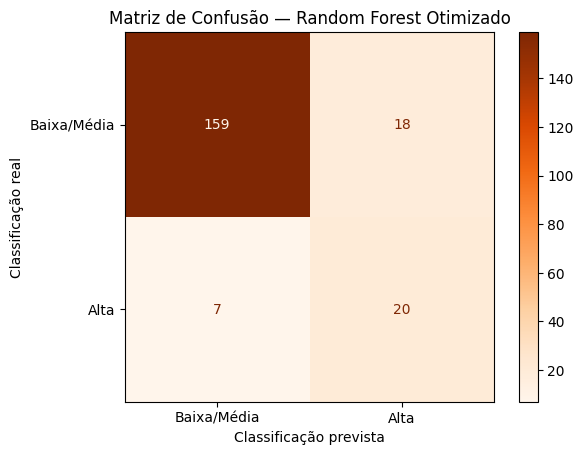

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_modelo_final,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Oranges',
    values_format='d'
)

plt.title(
    'Matriz de Confusão — Random Forest Otimizado'
)

plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

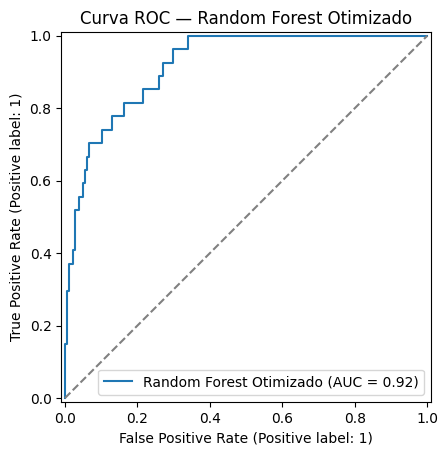

In [74]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_modelo_final,
    name='Random Forest Otimizado'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.title(
    'Curva ROC — Random Forest Otimizado'
)

plt.show()

## | Variáveis mais Relevantes

,variavel,importancia_media,desvio
10,alcohol,0.0757,0.0231
9,sulphates,0.0579,0.0158
1,volatile_acidity,0.0338,0.0166
6,total_sulfur_dioxide,0.0059,0.0062
2,citric_acid,0.0050,0.0047
8,ph,0.0019,0.0023
3,residual_sugar,0.0003,0.0024
4,chlorides,-0.0000,0.0011
0,fixed_acidity,-0.0004,0.0018
7,density,-0.0006,0.0054


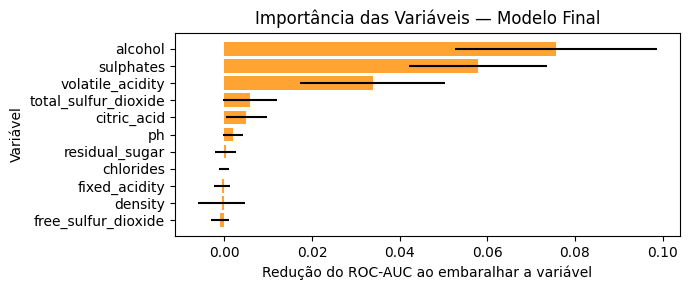

In [77]:
from sklearn.inspection import permutation_importance

importancia_permutacao = permutation_importance(
    estimator=modelo_final,
    X=X_teste,
    y=y_teste,
    scoring='roc_auc',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importancia_modelo_final = pd.DataFrame({
    'variavel': X_teste.columns,

    'importancia_media':
        importancia_permutacao.importances_mean,

    'desvio':
        importancia_permutacao.importances_std
}).sort_values(
    by='importancia_media',
    ascending=False
)

display(
    importancia_modelo_final.style.format({
        'importancia_media': '{:.4f}',
        'desvio': '{:.4f}'
    })
)


# Gráfico
importancia_grafico = (
    importancia_modelo_final
    .sort_values(
        by='importancia_media',
        ascending=True
    )
)

plt.figure(figsize=(7, 3))

plt.barh(
    importancia_grafico['variavel'],
    importancia_grafico['importancia_media'],
    xerr=importancia_grafico['desvio'],
    color='darkorange',
    alpha=0.8
)

plt.title(
    'Importância das Variáveis — Modelo Final'
)

plt.xlabel(
    'Redução do ROC-AUC ao embaralhar a variável'
)

plt.ylabel('Variável')
plt.tight_layout()
plt.show()

Nota:

O Random Forest otimizado apresentou acurácia de 87,75% e ROC-AUC de 91,82%. Entre os 27 vinhos de alta qualidade do conjunto de teste, o modelo conseguiu identificar 20, alcançando recall de 74,07%. A precisão ficou em 52,63%, o que mostra que pouco mais da metade dos vinhos classificados como alta qualidade realmente pertencia a essa categoria. Mesmo com essa limitação, o modelo apresentou o melhor equilíbrio entre precisão e recall, alcançando F1-score de 61,54%.


Impotância das Variáveis:

A análise de importância por permutação mostrou que álcool, sulfatos e acidez volátil foram as características que mais contribuíram para o resultado do modelo. O dióxido de enxofre total e o ácido cítrico também apresentaram alguma influência, mas em menor intensidade. Esses resultados indicam quais variáveis merecem maior atenção durante a análise exploratória, mas não comprovam que elas causam diretamente o aumento ou a redução da qualidade do vinho.

## || Conclusão Final da Modelagem

Após testar Regressão Logística, KNN, SVM e Random Forest, foram realizadas validação cruzada, criação de novas features, seleção de variáveis, divisão das características em faixas e otimização dos parâmetros. O Random Forest com cinco faixas criadas por K-Means e 500 árvores apresentou o melhor resultado geral. Dessa forma, ele foi escolhido como modelo final para apoiar a identificação de vinhos com maior potencial de qualidade.